<a href="https://colab.research.google.com/github/mountaindew93/2026-1_CV/blob/main/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# 시드 고정으로 동일 조건에서 재현되도록 함
np.random.seed(42)
tf.random.set_seed(42)

print("Import 및 환경 설정 완료")

Import 및 환경 설정 완료


In [ ]:
# 1. 실험 A, C를 위한 Fashion-MNIST 데이터셋
(X_train_raw, y_train_raw), (X_val_raw, y_val_raw) = tf.keras.datasets.fashion_mnist.load_data()

# 28x28 이미지를 784차원 1차원으로 평탄화 및 0~1 정규화 -> 학습 안정성 확보
X_train_f = X_train_raw.reshape(-1, 784) / 255.0
X_val_f = X_val_raw.reshape(-1, 784) / 255.0

# 다중 클래스 분류를 위한 One-hot Encoding
y_train_f = tf.one_hot(y_train_raw, 10)
y_val_f = tf.one_hot(y_val_raw, 10)

# tf.data를 64개씩 배치 단위로 묶고, Train 데이터는 섞음
ds_train_f = tf.data.Dataset.from_tensor_slices((X_train_f, y_train_f)).shuffle(10000).batch(64)
ds_val_f = tf.data.Dataset.from_tensor_slices((X_val_f, y_val_f)).batch(64)


# 2. make_moons 데이터셋
X_m, y_m = make_moons(n_samples=1000, noise=0.15, random_state=42)
X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(X_m, y_m, test_size=0.2, random_state=42)

y_train_m = tf.one_hot(y_train_m, 2)
y_val_m = tf.one_hot(y_val_m, 2)

ds_train_m = tf.data.Dataset.from_tensor_slices((X_train_m, y_train_m)).shuffle(1000).batch(64)
ds_val_m = tf.data.Dataset.from_tensor_slices((X_val_m, y_val_m)).batch(64)

print("데이터셋 로드 완료")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
데이터셋 로드 완료


In [ ]:
# 실험 A, C 공통 MLP 아키텍처 - 제시한 기본 네트워크 구조를 따름
def get_mnist_model():
    inputs = tf.keras.Input(shape=(784,))
    x1 = tf.keras.layers.Dense(256, activation='relu', name='fc1')(inputs)
    x2 = tf.keras.layers.Dense(128, activation='relu', name='fc2')(x1)
    outputs = tf.keras.layers.Dense(10, name='fc3')(x2)

    # 활성화 함수 분포(히스토그램) 시각화를 위해 x1, x2 반환
    return tf.keras.Model(inputs, [x1, x2, outputs])

# 실험 B 아키텍처
def get_activation_model(act_name):
    inputs = tf.keras.Input(shape=(2,))

    # Weight=0.01, Bias=-0.5 로 초기화하여 음수 입력을 유도
    w_init = tf.keras.initializers.RandomNormal(stddev=0.01)
    b_init = tf.keras.initializers.Constant(-0.5)

    x1 = tf.keras.layers.Dense(64, kernel_initializer=w_init, bias_initializer=b_init)(inputs)

    # 활성화 함수 변경
    act1 = tf.keras.layers.LeakyReLU(0.01)(x1) if act_name == 'leaky_relu' else tf.keras.layers.Activation(act_name)(x1)

    x2 = tf.keras.layers.Dense(64, kernel_initializer=w_init, bias_initializer=b_init)(act1)
    act2 = tf.keras.layers.LeakyReLU(0.01)(x2) if act_name == 'leaky_relu' else tf.keras.layers.Activation(act_name)(x2)

    outputs = tf.keras.layers.Dense(2)(act2)
    return tf.keras.Model(inputs, [act1, act2, outputs])

print("모델 생성 완료")

모델 생성 완료


In [ ]:
def run_exp_a(loss_type, epochs=30):
    print(f"\n--- 실험 A: {loss_type} 학습 시작 ---")
    tf.random.set_seed(42) # 실험 재현성 확보 위함

    model = get_mnist_model()
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    # CrossEntropy는 내부 logits을 그대로 사용, MSE는 softmax를 거친 확률값 사용
    loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True) if loss_type == 'Cross Entropy' else tf.keras.losses.MeanSquaredError()

    # 결과 저장 딕셔너리
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
               'grad_init_fc1': None, 'grad_init_fc3': None,
               'grad_final_fc1': None, 'grad_final_fc3': None}

    total_batches = len(ds_train_f)


    # 학습 루프를 for문으로 작성
    for epoch in range(epochs):
        loss_metric = tf.keras.metrics.Mean(); acc_metric = tf.keras.metrics.CategoricalAccuracy()


        # 학습 루프
        for batch_idx, (x, y) in enumerate(ds_train_f):
            with tf.GradientTape() as tape: # 자동 미분 사용
                _, _, logits = model(x, training=True)
                preds = tf.nn.softmax(logits)

                # 손실 계산
                loss = loss_fn(y, logits) if loss_type == 'Cross Entropy' else loss_fn(y, preds)

            # 역전파 수행, 가중치 업데이트
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            loss_metric.update_state(loss); acc_metric.update_state(y, preds)

            # 첫 배치와 마지막 배치의 가중치 기울기 분포 저장
            # grads[0]: 첫 번째 은닉층(fc1)의 가중치 기울기, grads[-2]: 출력층(fc3)의 가중치 기울기
            if epoch == 0 and batch_idx == 0:
                history['grad_init_fc1'] = grads[0].numpy()
                history['grad_init_fc3'] = grads[-2].numpy()
            if epoch == epochs - 1 and batch_idx == total_batches - 1:
                history['grad_final_fc1'] = grads[0].numpy()
                history['grad_final_fc3'] = grads[-2].numpy()

        # 평가
        val_acc_metric = tf.keras.metrics.CategoricalAccuracy()
        val_loss_metric = tf.keras.metrics.Mean()

        # training=False를 주어 Dropout/BatchNorm 등의 훈련 전용 동작 비활성화
        for x_val, y_val in ds_val_f:
            _, _, val_logits = model(x_val, training=False)
            val_preds = tf.nn.softmax(val_logits)
            val_loss = loss_fn(y_val, val_logits) if loss_type == 'Cross Entropy' else loss_fn(y_val, val_preds)
            val_loss_metric.update_state(val_loss); val_acc_metric.update_state(y_val, val_preds)

        # 결과 저장
        history['train_loss'].append(loss_metric.result().numpy())
        history['train_acc'].append(acc_metric.result().numpy())
        history['val_loss'].append(val_loss_metric.result().numpy())
        history['val_acc'].append(val_acc_metric.result().numpy())

        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {history['train_loss'][-1]:.4f} | Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]*100:.2f}%")

    return history

EPOCHS_A = 30
res_ce = run_exp_a('Cross Entropy', epochs=EPOCHS_A)
res_mse = run_exp_a('MSE', epochs=EPOCHS_A)


--- 실험 A: Cross Entropy 학습 시작 ---
Epoch 01/30 | Train Loss: 0.4902 | Val Loss: 0.4081 | Val Acc: 85.19%
Epoch 02/30 | Train Loss: 0.3617 | Val Loss: 0.3612 | Val Acc: 86.46%
Epoch 03/30 | Train Loss: 0.3258 | Val Loss: 0.3564 | Val Acc: 86.87%
Epoch 04/30 | Train Loss: 0.3006 | Val Loss: 0.3605 | Val Acc: 87.00%
Epoch 05/30 | Train Loss: 0.2835 | Val Loss: 0.3400 | Val Acc: 87.50%
Epoch 06/30 | Train Loss: 0.2699 | Val Loss: 0.3428 | Val Acc: 87.83%
Epoch 07/30 | Train Loss: 0.2579 | Val Loss: 0.3307 | Val Acc: 88.32%
Epoch 08/30 | Train Loss: 0.2461 | Val Loss: 0.3230 | Val Acc: 88.28%
Epoch 09/30 | Train Loss: 0.2363 | Val Loss: 0.3313 | Val Acc: 88.36%
Epoch 10/30 | Train Loss: 0.2246 | Val Loss: 0.3284 | Val Acc: 88.57%
Epoch 11/30 | Train Loss: 0.2154 | Val Loss: 0.3254 | Val Acc: 88.89%
Epoch 12/30 | Train Loss: 0.2105 | Val Loss: 0.3367 | Val Acc: 88.75%
Epoch 13/30 | Train Loss: 0.2020 | Val Loss: 0.3391 | Val Acc: 88.79%
Epoch 14/30 | Train Loss: 0.1921 | Val Loss: 0.3352 | V

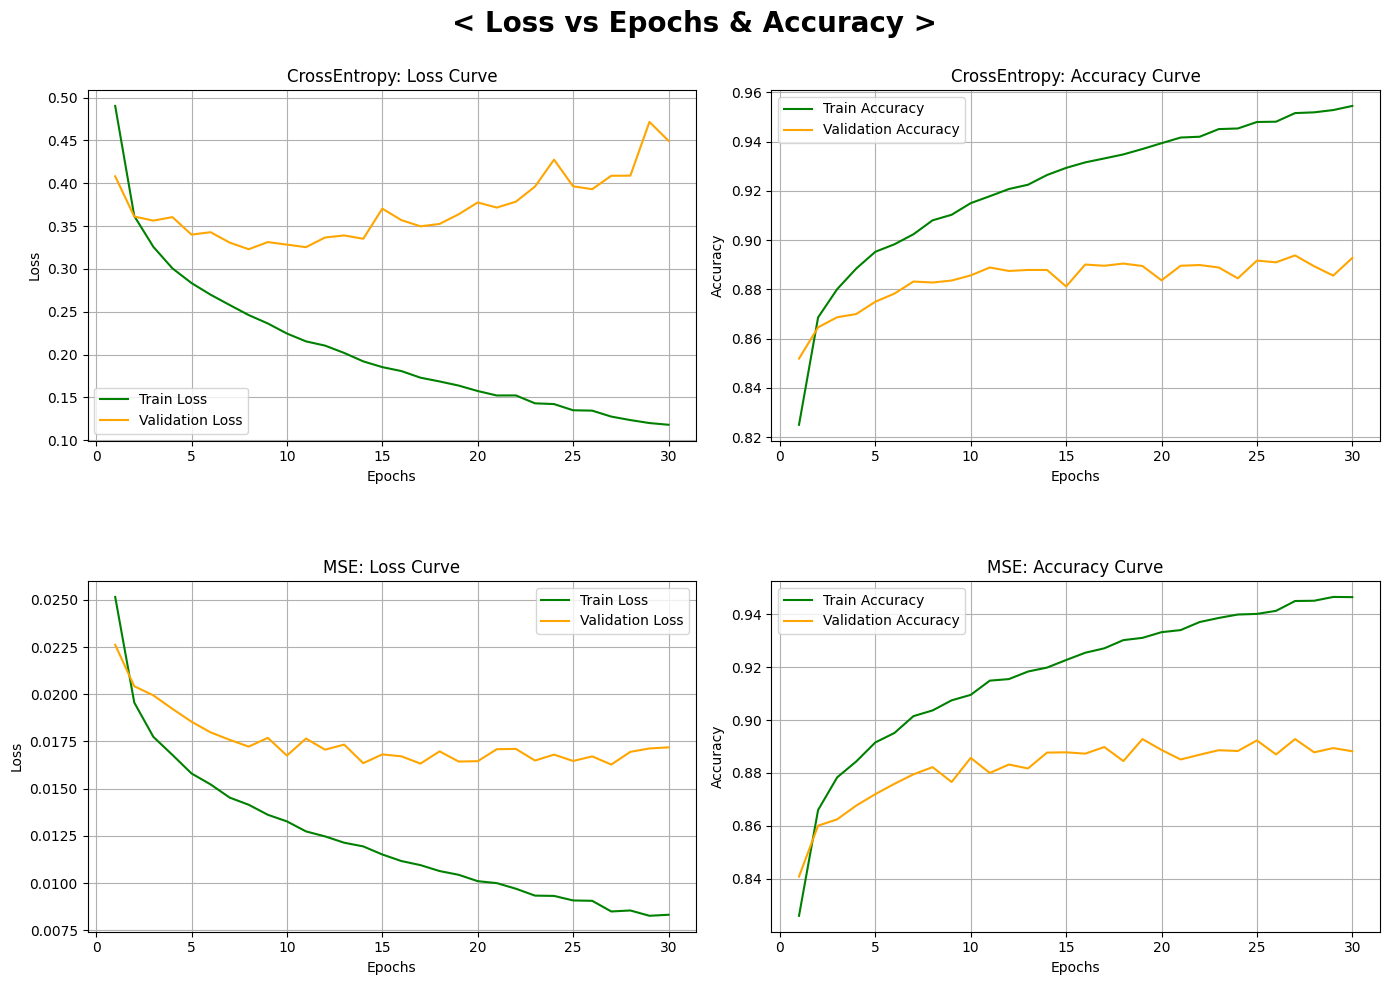

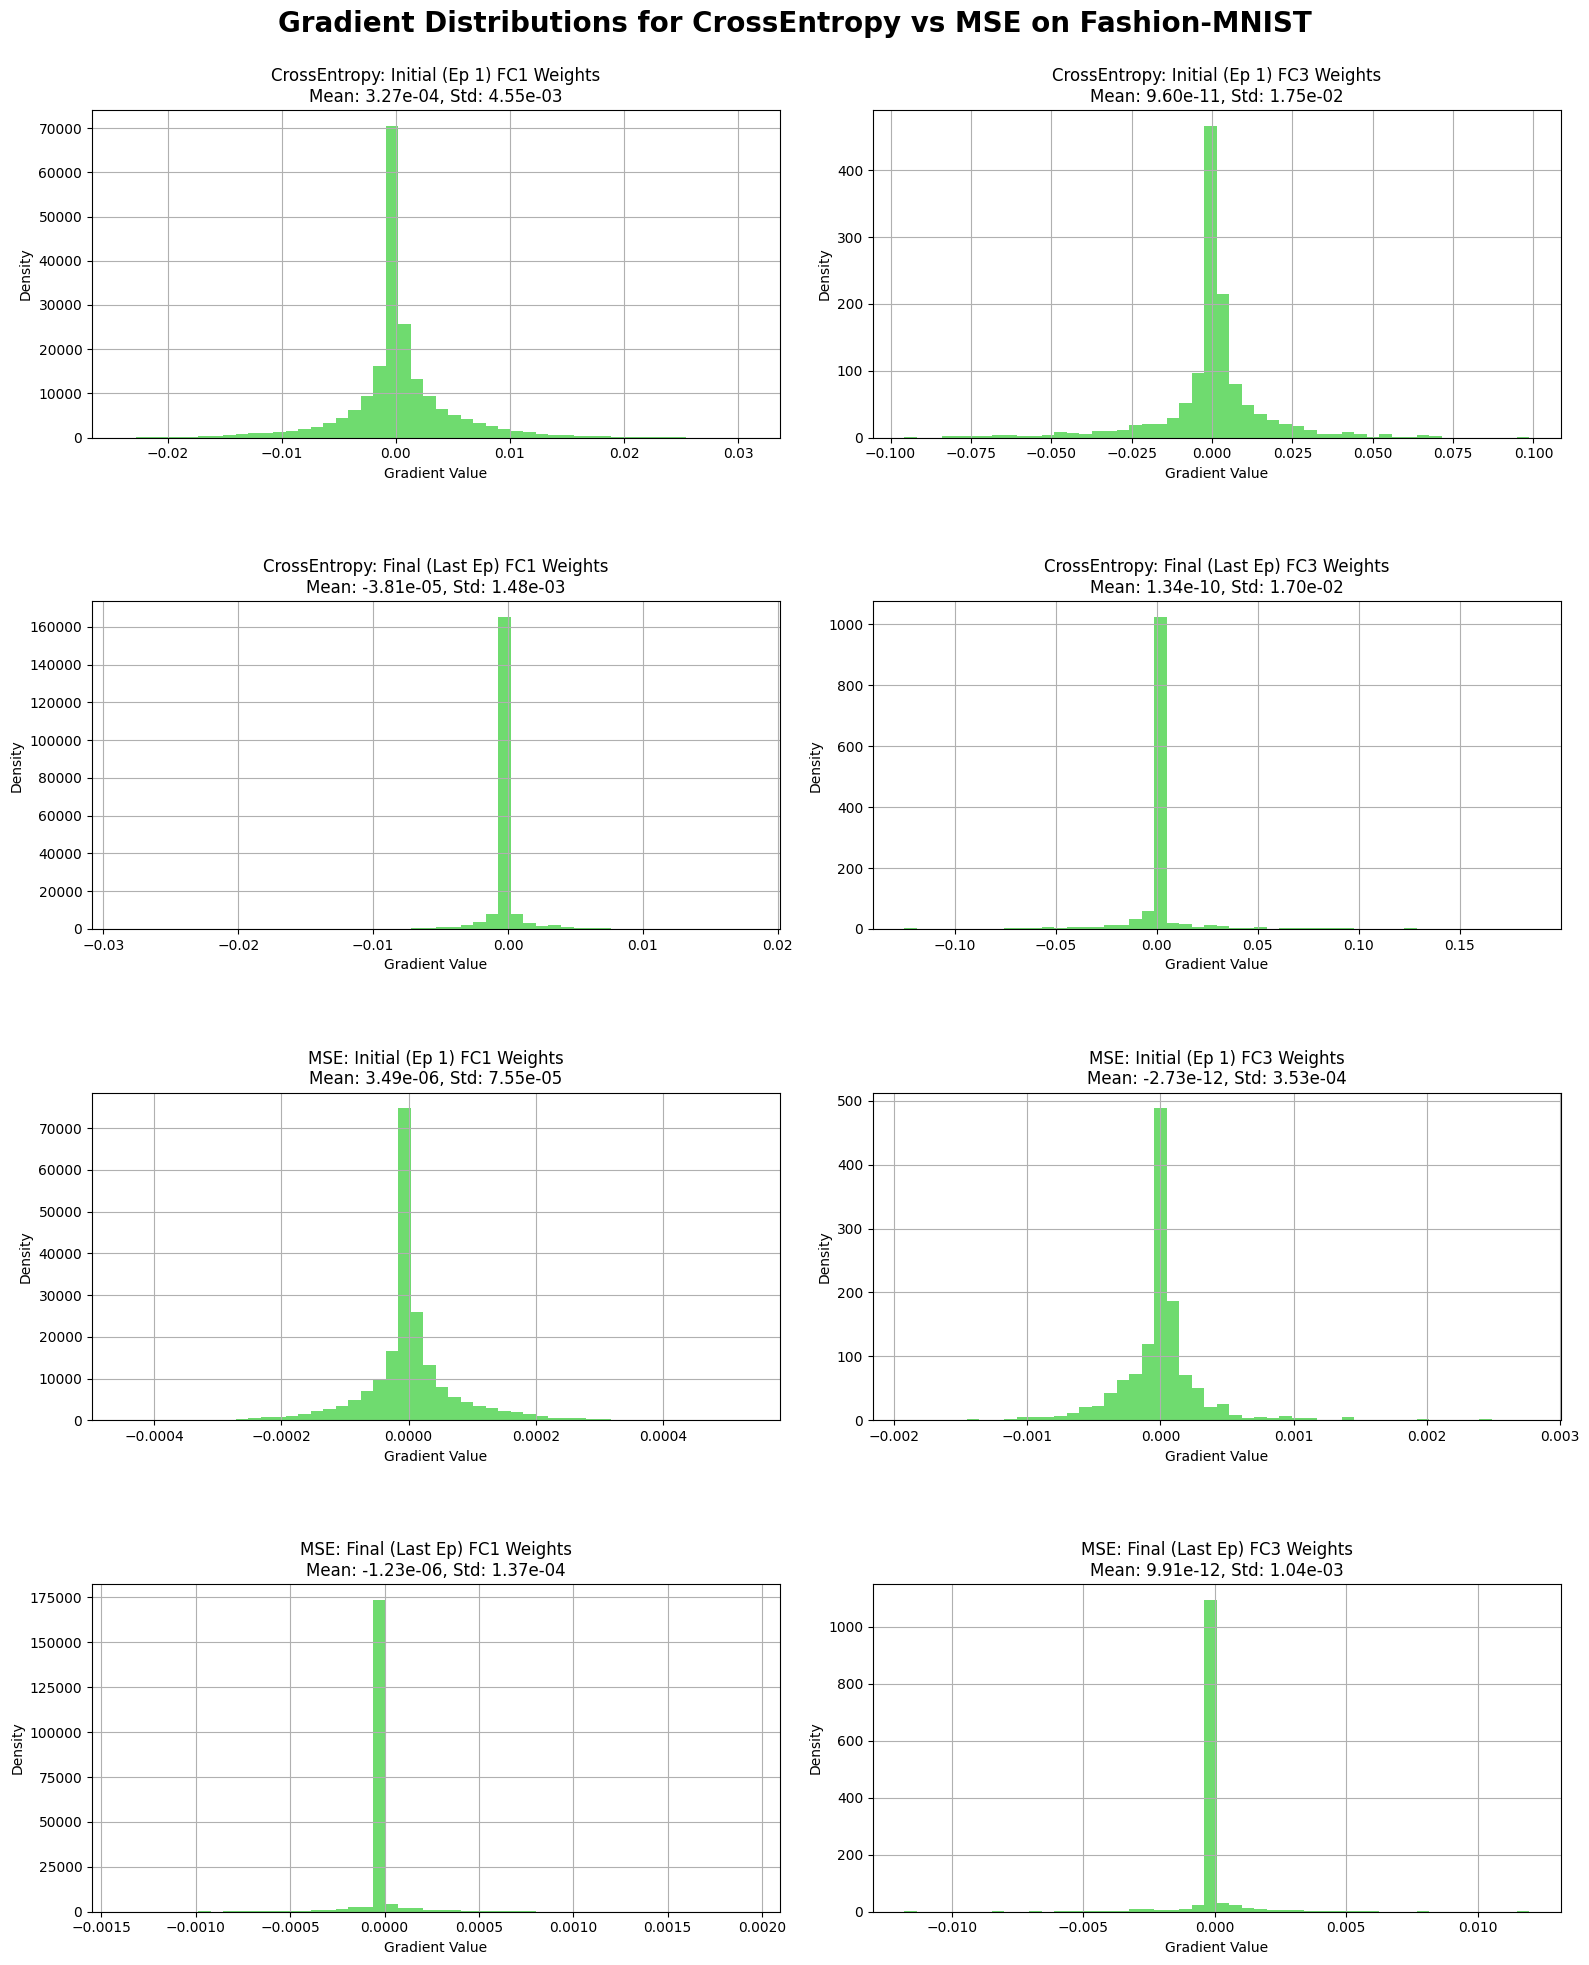

In [ ]:
epochs_range = range(1, EPOCHS_A + 1)

# Loss & Accuracy 비교
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))

# CrossEntropy
axes1[0, 0].plot(epochs_range, res_ce['train_loss'], label='Train Loss', color='g')
axes1[0, 0].plot(epochs_range, res_ce['val_loss'], label='Validation Loss', color='orange')
axes1[0, 0].set_title('CrossEntropy: Loss Curve')
axes1[0, 0].set_xlabel('Epochs'); axes1[0, 0].set_ylabel('Loss'); axes1[0, 0].legend(); axes1[0, 0].grid(True)

axes1[0, 1].plot(epochs_range, res_ce['train_acc'], label='Train Accuracy', color='g')
axes1[0, 1].plot(epochs_range, res_ce['val_acc'], label='Validation Accuracy', color='orange')
axes1[0, 1].set_title('CrossEntropy: Accuracy Curve')
axes1[0, 1].set_xlabel('Epochs'); axes1[0, 1].set_ylabel('Accuracy'); axes1[0, 1].legend(); axes1[0, 1].grid(True)

# MSE
axes1[1, 0].plot(epochs_range, res_mse['train_loss'], label='Train Loss', color='g')
axes1[1, 0].plot(epochs_range, res_mse['val_loss'], label='Validation Loss', color='orange')
axes1[1, 0].set_title('MSE: Loss Curve')
axes1[1, 0].set_xlabel('Epochs'); axes1[1, 0].set_ylabel('Loss'); axes1[1, 0].legend(); axes1[1, 0].grid(True)

axes1[1, 1].plot(epochs_range, res_mse['train_acc'], label='Train Accuracy', color='g')
axes1[1, 1].plot(epochs_range, res_mse['val_acc'], label='Validation Accuracy', color='orange')
axes1[1, 1].set_title('MSE: Accuracy Curve')
axes1[1, 1].set_xlabel('Epochs'); axes1[1, 1].set_ylabel('Accuracy'); axes1[1, 1].legend(); axes1[1, 1].grid(True)

fig1.tight_layout()
fig1.subplots_adjust(top=0.9, hspace=0.4)
fig1.suptitle('< Loss vs Epochs & Accuracy >', fontsize=20, fontweight='bold')
plt.show()

# FC1 & FC3 히스토그램
def plot_grad_hist(ax, grad_data, title):
    ax.hist(grad_data.flatten(), bins=50, alpha=0.7, color='limegreen')

    ax.set_title(f"{title}\nMean: {np.mean(grad_data):.2e}, Std: {np.std(grad_data):.2e}")
    ax.set_xlabel('Gradient Value')
    ax.set_ylabel('Density')
    ax.grid(True)

fig2, axes2 = plt.subplots(4, 2, figsize=(16, 20))

# CrossEntropy 그래디언트
plot_grad_hist(axes2[0, 0], res_ce['grad_init_fc1'], "CrossEntropy: Initial (Ep 1) FC1 Weights")
plot_grad_hist(axes2[0, 1], res_ce['grad_init_fc3'], "CrossEntropy: Initial (Ep 1) FC3 Weights")
plot_grad_hist(axes2[1, 0], res_ce['grad_final_fc1'], "CrossEntropy: Final (Last Ep) FC1 Weights")
plot_grad_hist(axes2[1, 1], res_ce['grad_final_fc3'], "CrossEntropy: Final (Last Ep) FC3 Weights")

# MSE 그래디언트
plot_grad_hist(axes2[2, 0], res_mse['grad_init_fc1'], "MSE: Initial (Ep 1) FC1 Weights")
plot_grad_hist(axes2[2, 1], res_mse['grad_init_fc3'], "MSE: Initial (Ep 1) FC3 Weights")
plot_grad_hist(axes2[3, 0], res_mse['grad_final_fc1'], "MSE: Final (Last Ep) FC1 Weights")
plot_grad_hist(axes2[3, 1], res_mse['grad_final_fc3'], "MSE: Final (Last Ep) FC3 Weights")

fig2.tight_layout()
fig2.subplots_adjust(top=0.93, hspace=0.5)
fig2.suptitle('Gradient Distributions for CrossEntropy vs MSE on Fashion-MNIST', fontsize=20, fontweight='bold')
plt.show()

In [ ]:
def run_exp_b(act_name, epochs=250):
    print(f"\n--- 실험 B: {act_name} 학습 시작 ---")
    tf.random.set_seed(42)

    # 정의한 모델 불러오기
    model = get_activation_model(act_name)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
    loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)

    # 결과 저장 (h2 데이터 저장 공간 추가)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
               'grad_mean': [], 'act_early': None, 'act_mid': None, 'act_late': None,
               'act2_early': None, 'act2_mid': None, 'act2_late': None}

    # 학습 루프
    for epoch in range(epochs):
        t_loss = tf.keras.metrics.Mean(); t_acc = tf.keras.metrics.CategoricalAccuracy()
        grads_epoch = []

        for x, y in ds_train_m:
            with tf.GradientTape() as tape:
                _, _, logits = model(x, training=True)
                loss = loss_fn(y, logits)

            # 미분으로 기울기 계산, 가중치 업데이트
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            # 첫 번째 레이어의 기울기
            grads_epoch.append(tf.reduce_mean(tf.abs(grads[0])).numpy()) # Layer 1 Gradient
            t_loss.update_state(loss); t_acc.update_state(y, tf.nn.softmax(logits))

        # 평가
        v_loss = tf.keras.metrics.Mean(); v_acc = tf.keras.metrics.CategoricalAccuracy()
        for x_val, y_val in ds_val_m:
            _, _, val_logits = model(x_val, training=False)
            v_loss.update_state(loss_fn(y_val, val_logits))
            v_acc.update_state(y_val, tf.nn.softmax(val_logits))

        history['train_loss'].append(t_loss.result().numpy())
        history['train_acc'].append(t_acc.result().numpy())
        history['val_loss'].append(v_loss.result().numpy())
        history['val_acc'].append(v_acc.result().numpy())
        history['grad_mean'].append(np.mean(grads_epoch))

        # 활성화 함수 분포 캡처 -> 1, 125, 250 시점 (h1, h2 모두 저장)
        if epoch == 0:
            h1, h2, _ = model(X_val_m, training=False)
            history['act_early'] = h1.numpy(); history['act2_early'] = h2.numpy()
        elif epoch == epochs // 2:
            h1, h2, _ = model(X_val_m, training=False)
            history['act_mid'] = h1.numpy(); history['act2_mid'] = h2.numpy()
        elif epoch == epochs - 1:
            h1, h2, _ = model(X_val_m, training=False)
            history['act_late'] = h1.numpy(); history['act2_late'] = h2.numpy()

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | Val Acc: {history['val_acc'][-1]*100:.2f}% | L1 Grad: {history['grad_mean'][-1]:.6f}")

    # 결정 경계 시각화를 위한 2D Grid 데이터 예측
    xx, yy = np.meshgrid(np.linspace(-2.5, 3.5, 100), np.linspace(-2.0, 2.5, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    _, _, grid_logits = model(grid, training=False)
    history['decision_z'] = tf.argmax(tf.nn.softmax(grid_logits), axis=1).numpy().reshape(xx.shape)
    history['xx'] = xx; history['yy'] = yy

    # 히트맵용 최종 출력
    act1_out, _, _ = model(X_val_m, training=False)
    history['final_act1'] = act1_out.numpy()

    return history

EPOCHS_B = 250
res_relu = run_exp_b('relu', epochs=EPOCHS_B)
res_leaky = run_exp_b('leaky_relu', epochs=EPOCHS_B)
res_sig = run_exp_b('sigmoid', epochs=EPOCHS_B)


--- 실험 B: relu 학습 시작 ---
Epoch 001/250 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 010/250 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 020/250 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 030/250 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 040/250 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 050/250 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 060/250 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 070/250 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 080/250 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 090/250 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 100/250 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 110/250 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 120/250 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 130/250 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 140/250 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 150/250 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 160/250 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 170/250 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 180/250 | Val Acc: 50.00% | L1 G

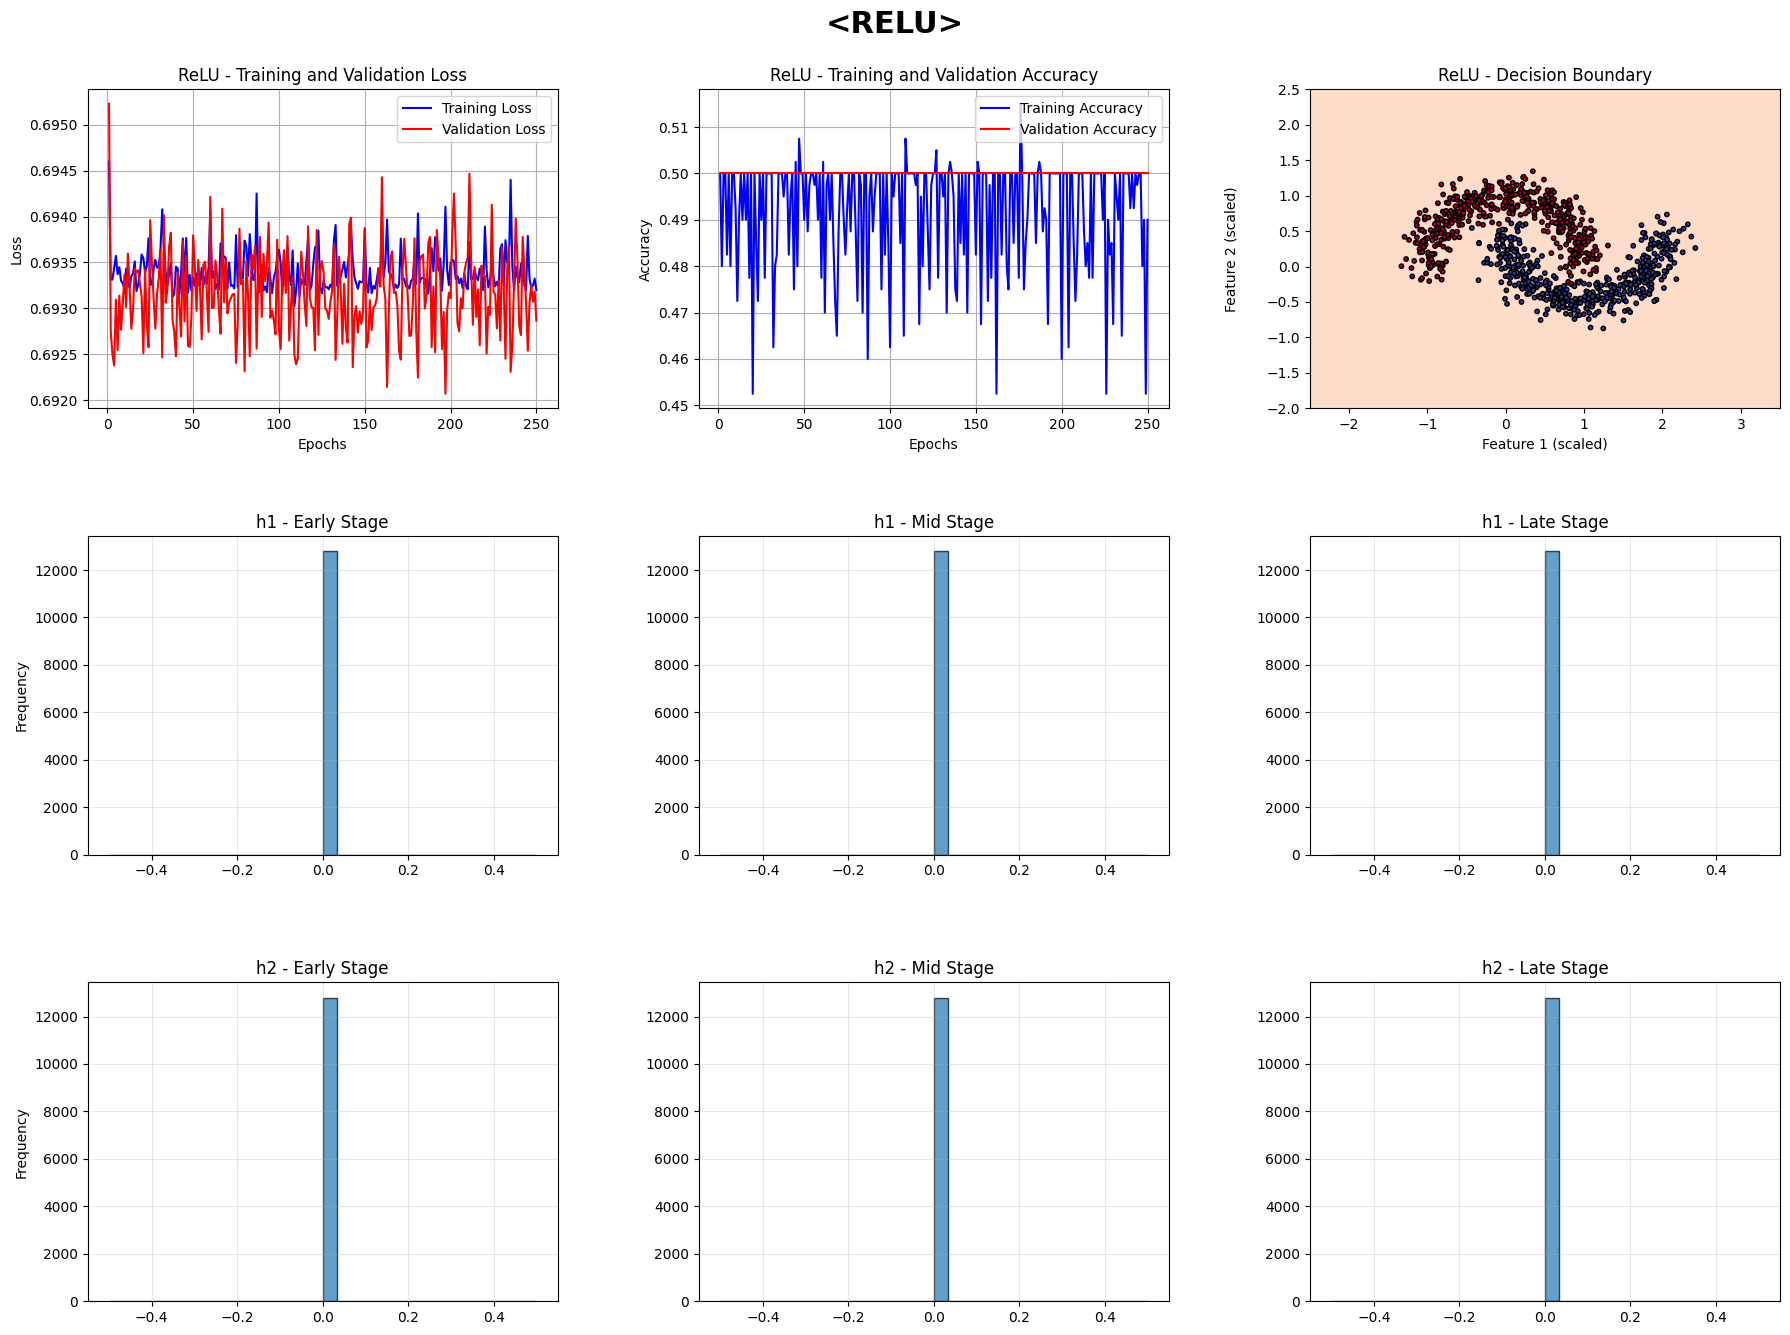

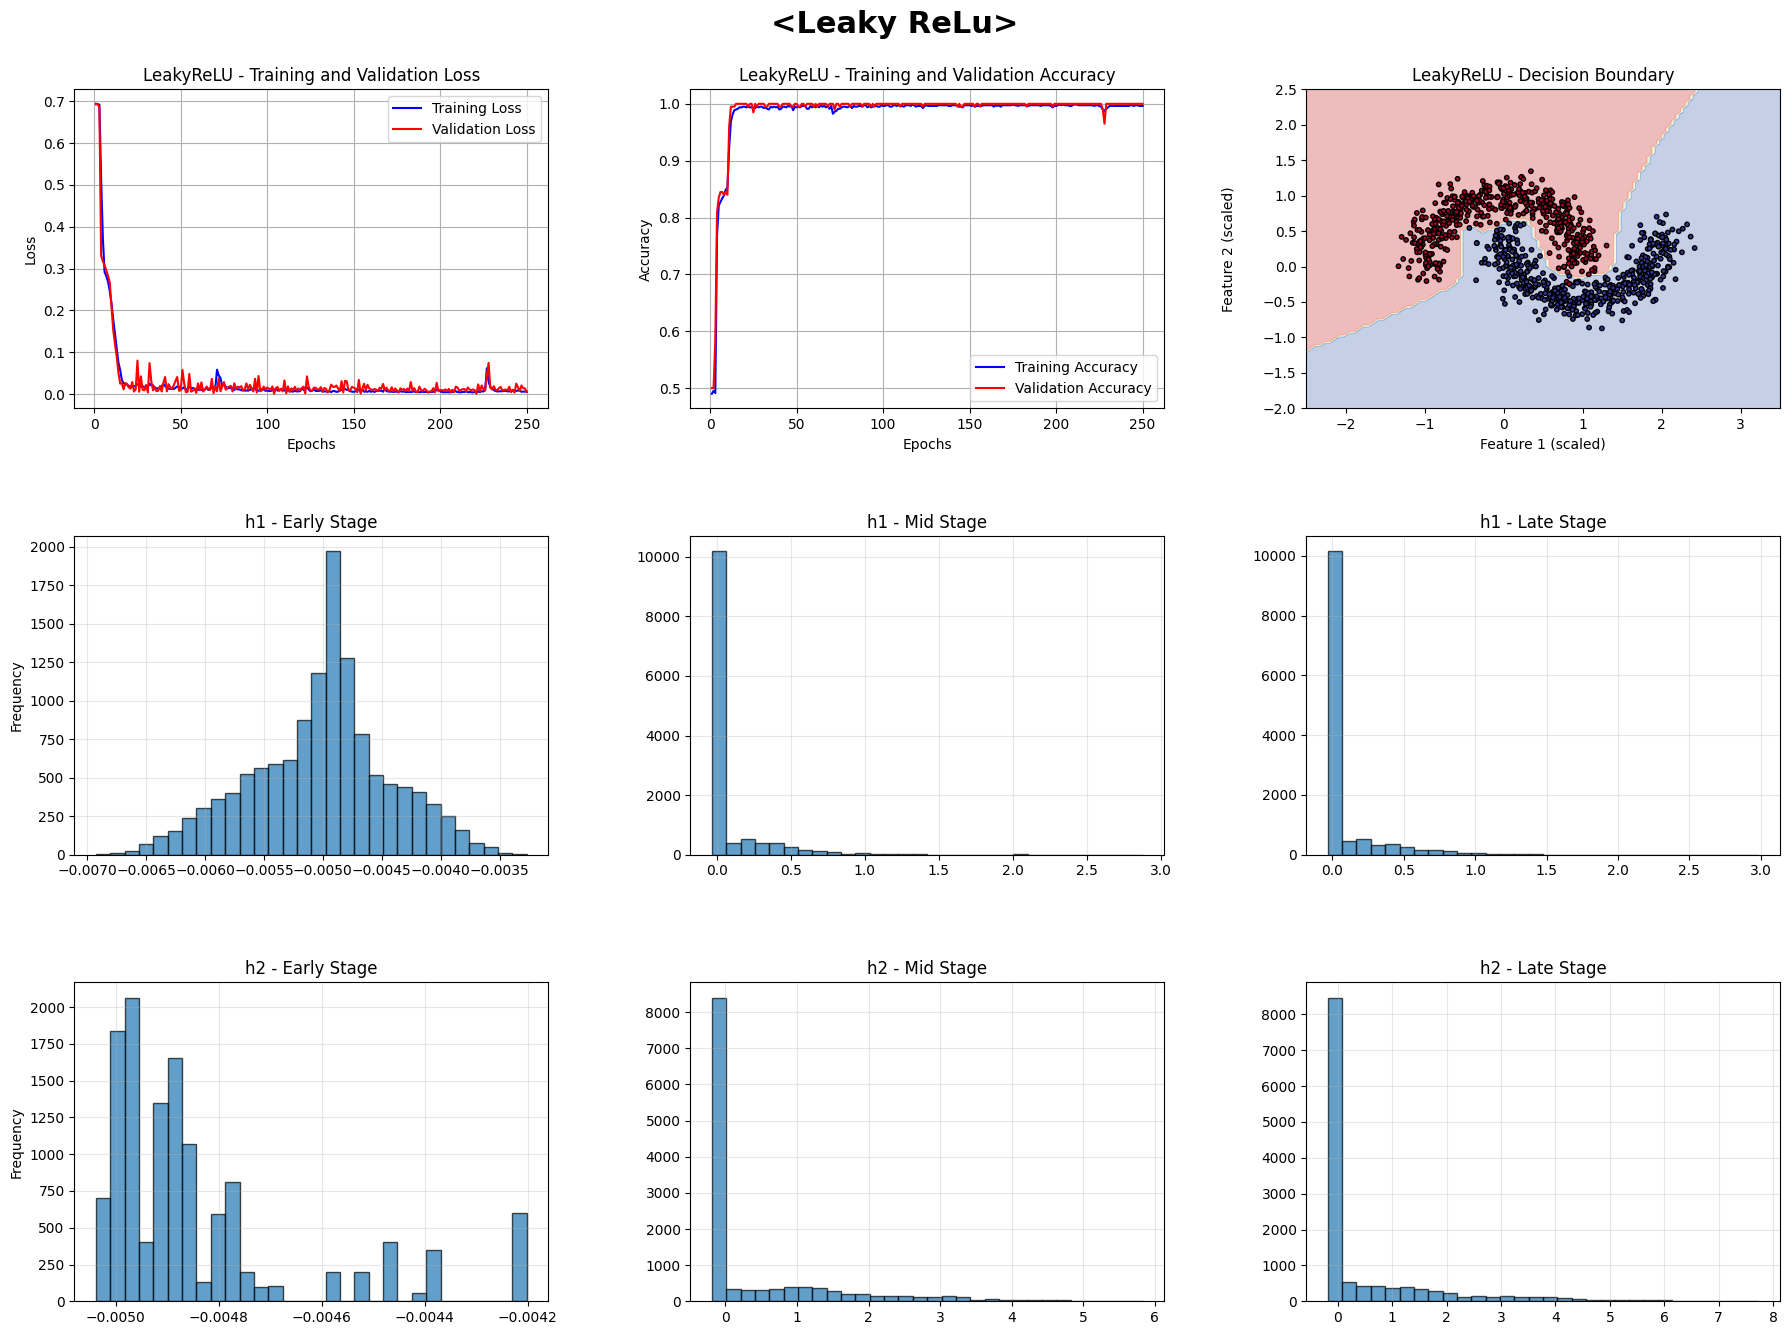

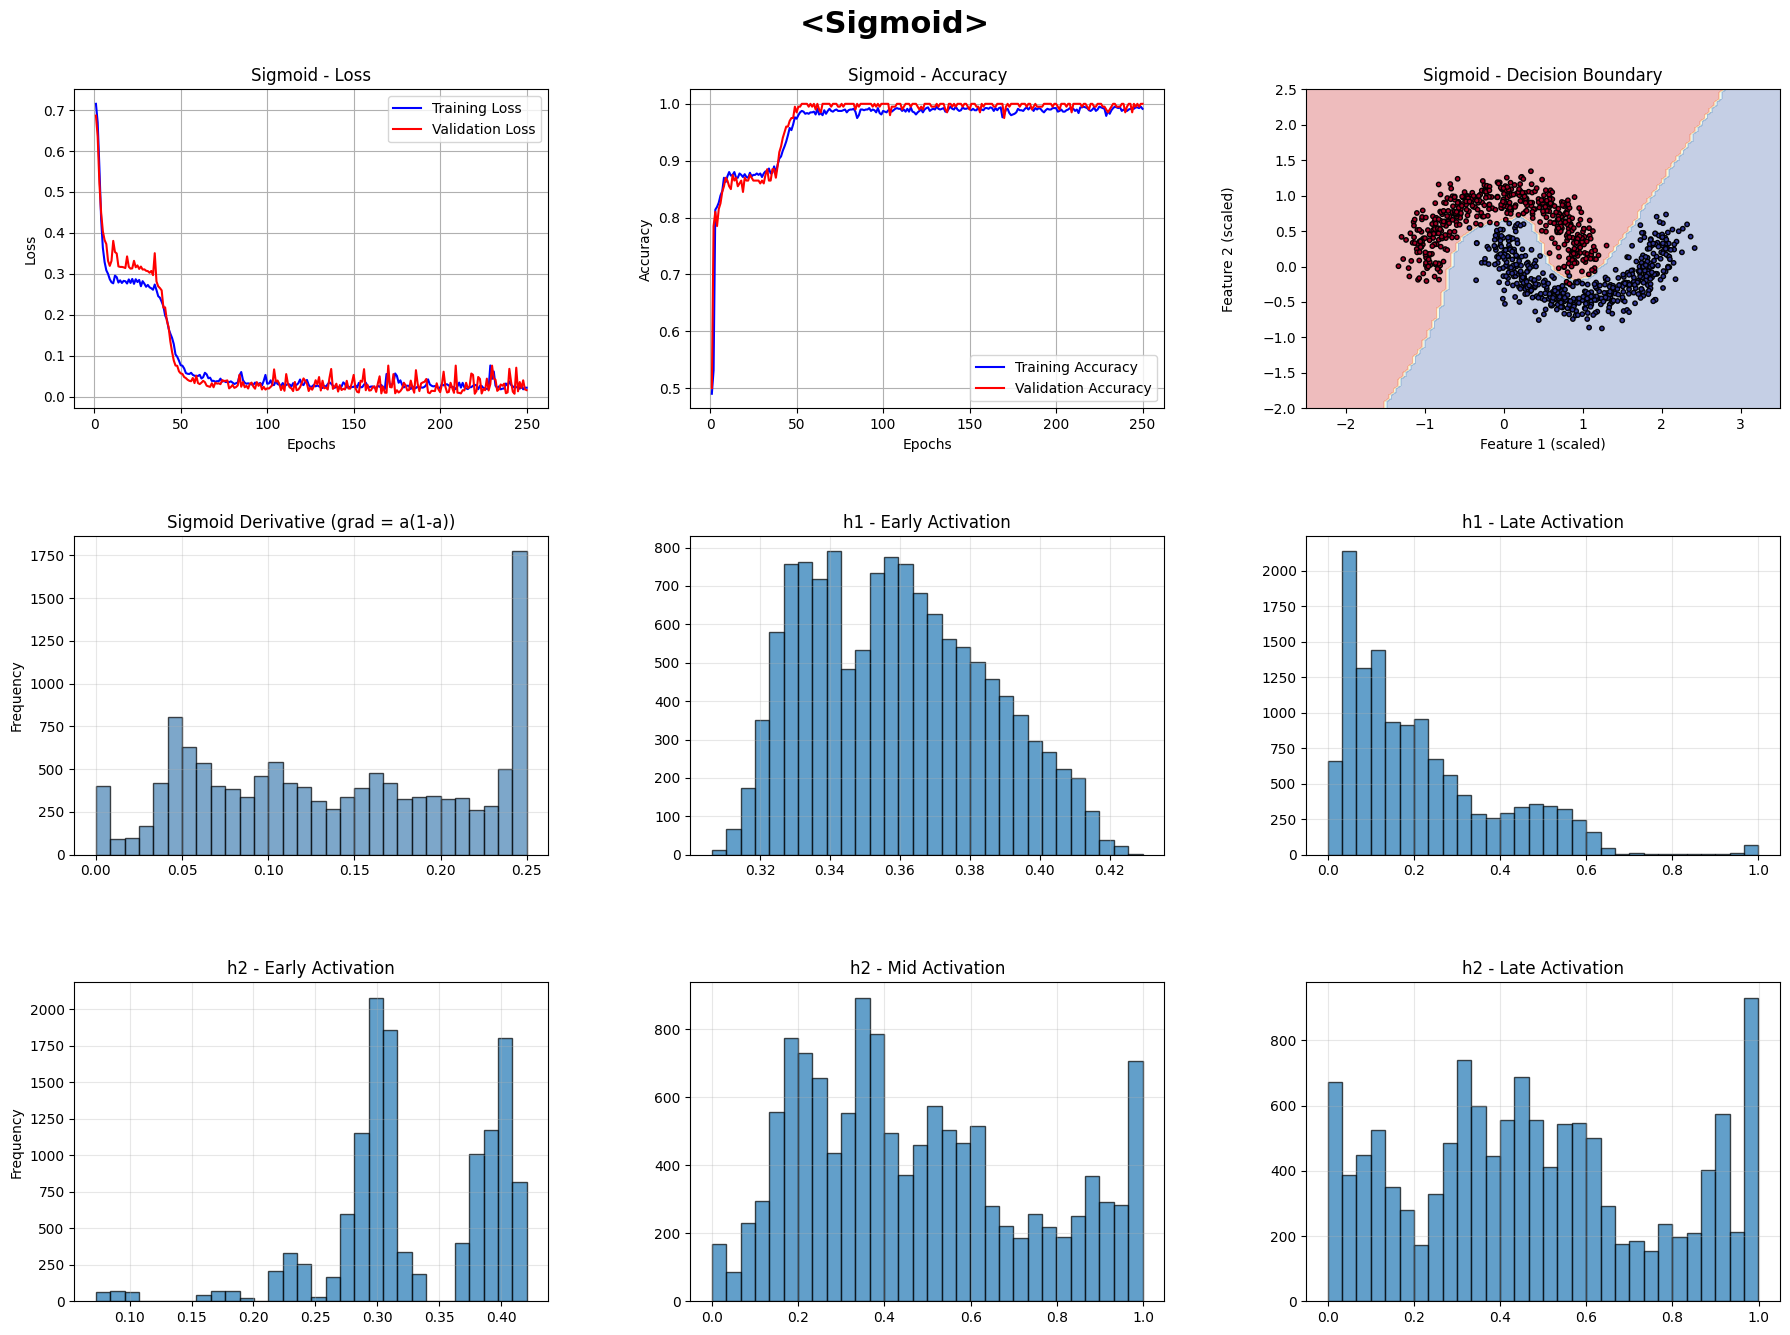

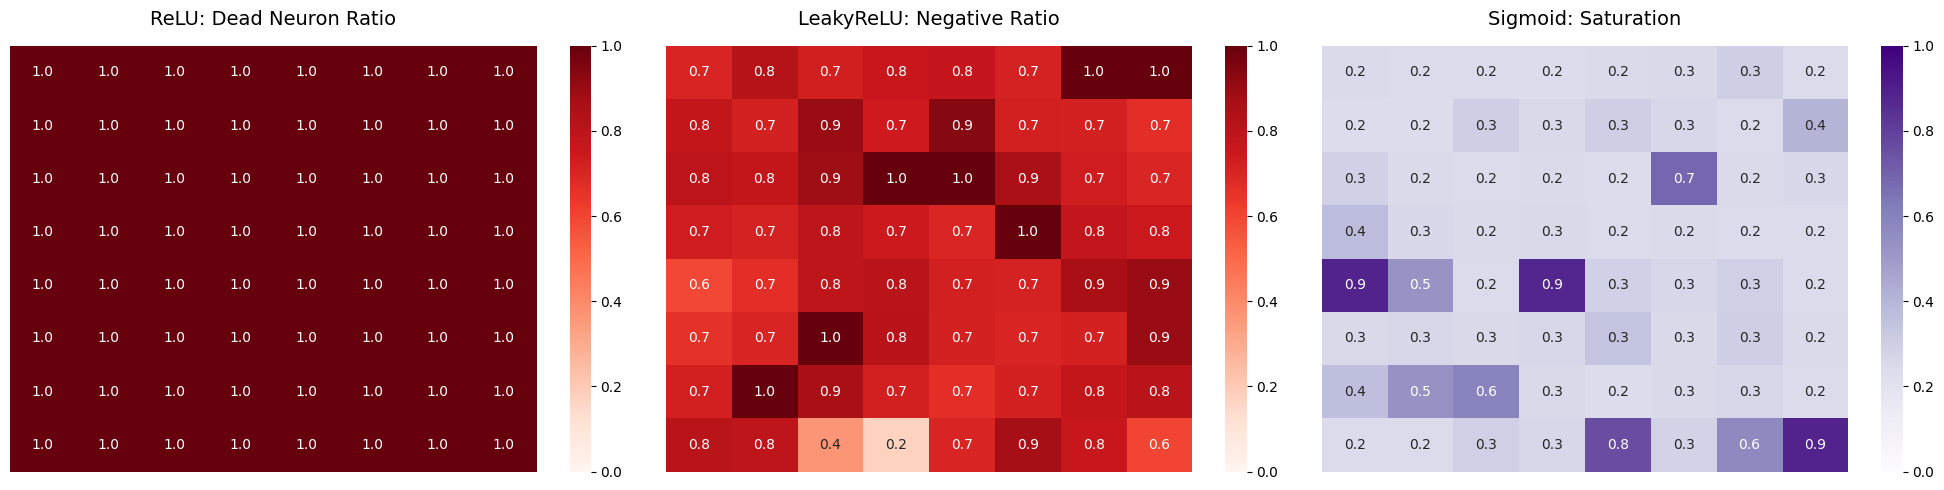

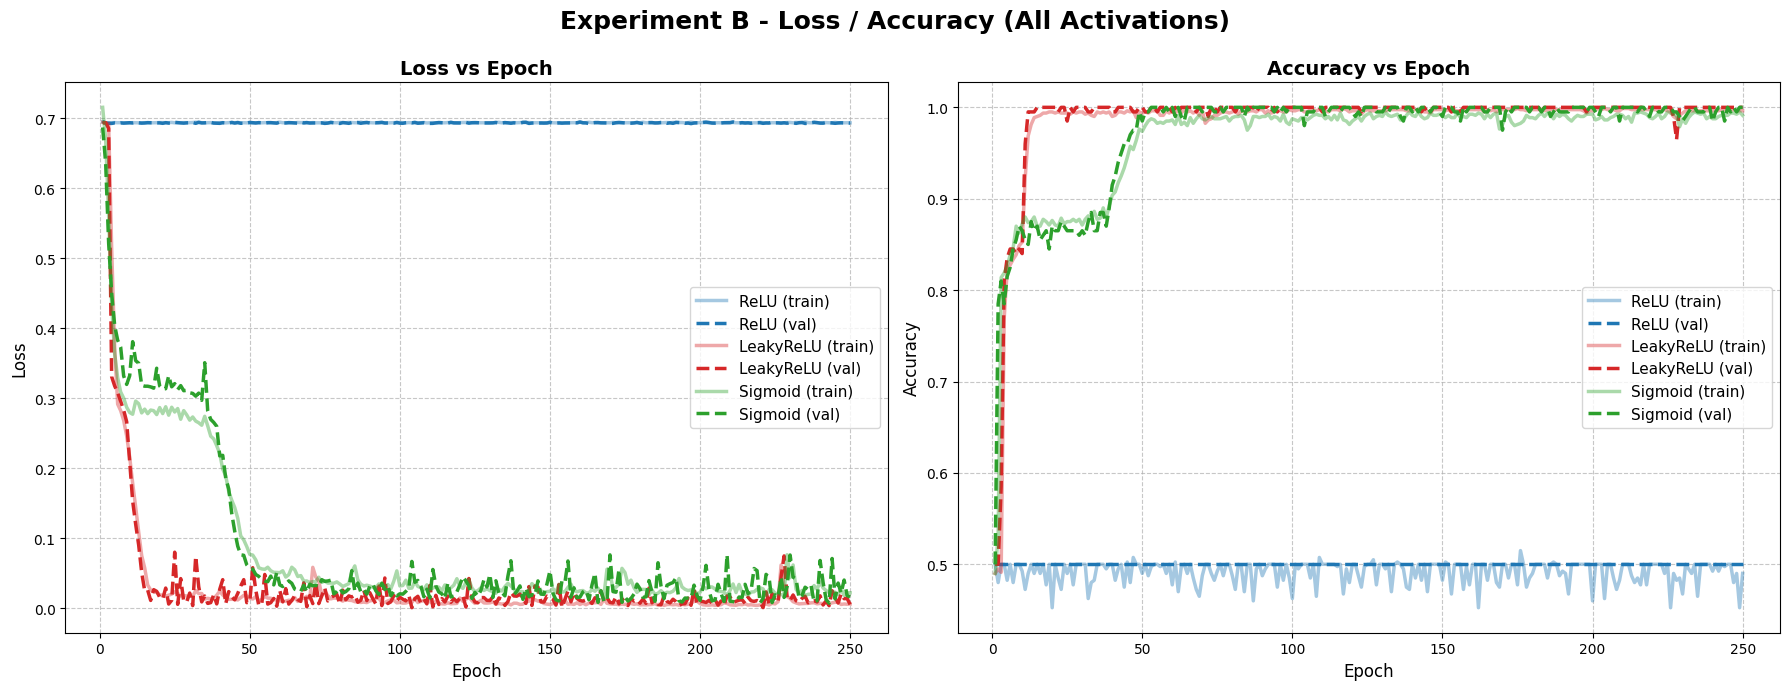

In [ ]:

e_range = range(1, EPOCHS_B + 1)

# 1. ReLU
fig_relu = plt.figure(figsize=(18, 14))

plt.subplot(3, 3, 1)
plt.plot(e_range, res_relu['train_loss'], 'b-', label='Training Loss')
plt.plot(e_range, res_relu['val_loss'], 'r-', label='Validation Loss')
plt.title('ReLU - Training and Validation Loss'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(3, 3, 2)
plt.plot(e_range, res_relu['train_acc'], 'b-', label='Training Accuracy')
plt.plot(e_range, res_relu['val_acc'], 'r-', label='Validation Accuracy')
plt.title('ReLU - Training and Validation Accuracy'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

plt.subplot(3, 3, 3)
plt.contourf(res_relu['xx'], res_relu['yy'], res_relu['decision_z'], alpha=0.3, cmap=plt.cm.RdYlBu)
plt.scatter(X_m[:, 0], X_m[:, 1], c=y_m, s=10, edgecolor='k', cmap=plt.cm.RdYlBu)
# labelpad=20 을 주어 글자가 그래프 안으로 파고드는 것을 방지
plt.title('ReLU - Decision Boundary'); plt.xlabel('Feature 1 (scaled)'); plt.ylabel('Feature 2 (scaled)', labelpad=20)

# --- h1 레이어 히스토그램 ---
plt.subplot(3, 3, 4)
plt.hist(res_relu['act_early'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h1 - Early Stage'); plt.ylabel('Frequency'); plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 5)
plt.hist(res_relu['act_mid'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h1 - Mid Stage'); plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 6)
plt.hist(res_relu['act_late'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h1 - Late Stage'); plt.grid(True, alpha=0.3)

# --- h2 레이어 히스토그램 (새로 추가) ---
plt.subplot(3, 3, 7)
plt.hist(res_relu['act2_early'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h2 - Early Stage'); plt.ylabel('Frequency'); plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 8)
plt.hist(res_relu['act2_mid'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h2 - Mid Stage'); plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 9)
plt.hist(res_relu['act2_late'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h2 - Late Stage'); plt.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 맨 위에 메인 타이틀이 들어갈 공간 확보
plt.subplots_adjust(hspace=0.4, wspace=0.3)
fig_relu.suptitle('<RELU>', fontsize=22, fontweight='bold')
plt.show()


# 2. LeakyReLU
fig_leaky = plt.figure(figsize=(18, 14))

plt.subplot(3, 3, 1)
plt.plot(e_range, res_leaky['train_loss'], 'b-', label='Training Loss')
plt.plot(e_range, res_leaky['val_loss'], 'r-', label='Validation Loss')
plt.title('LeakyReLU - Training and Validation Loss'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(3, 3, 2)
plt.plot(e_range, res_leaky['train_acc'], 'b-', label='Training Accuracy')
plt.plot(e_range, res_leaky['val_acc'], 'r-', label='Validation Accuracy')
plt.title('LeakyReLU - Training and Validation Accuracy'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

plt.subplot(3, 3, 3)
plt.contourf(res_leaky['xx'], res_leaky['yy'], res_leaky['decision_z'], alpha=0.3, cmap=plt.cm.RdYlBu)
plt.scatter(X_m[:, 0], X_m[:, 1], c=y_m, s=10, edgecolor='k', cmap=plt.cm.RdYlBu)
plt.title('LeakyReLU - Decision Boundary'); plt.xlabel('Feature 1 (scaled)'); plt.ylabel('Feature 2 (scaled)', labelpad=20)

# --- h1 레이어 히스토그램 ---
plt.subplot(3, 3, 4)
plt.hist(res_leaky['act_early'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h1 - Early Stage'); plt.ylabel('Frequency'); plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 5)
plt.hist(res_leaky['act_mid'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h1 - Mid Stage'); plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 6)
plt.hist(res_leaky['act_late'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h1 - Late Stage'); plt.grid(True, alpha=0.3)

# --- h2 레이어 히스토그램 (새로 추가) ---
plt.subplot(3, 3, 7)
plt.hist(res_leaky['act2_early'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h2 - Early Stage'); plt.ylabel('Frequency'); plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 8)
plt.hist(res_leaky['act2_mid'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h2 - Mid Stage'); plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 9)
plt.hist(res_leaky['act2_late'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h2 - Late Stage'); plt.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.subplots_adjust(hspace=0.4, wspace=0.3)
fig_leaky.suptitle('<Leaky ReLu>', fontsize=22, fontweight='bold')
plt.show()


# 3. Sigmoid
fig_sig = plt.figure(figsize=(18, 14))

plt.subplot(3, 3, 1)
plt.plot(e_range, res_sig['train_loss'], 'b-', label='Training Loss')
plt.plot(e_range, res_sig['val_loss'], 'r-', label='Validation Loss')
plt.title('Sigmoid - Loss'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(3, 3, 2)
plt.plot(e_range, res_sig['train_acc'], 'b-', label='Training Accuracy')
plt.plot(e_range, res_sig['val_acc'], 'r-', label='Validation Accuracy')
plt.title('Sigmoid - Accuracy'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

plt.subplot(3, 3, 3)
plt.contourf(res_sig['xx'], res_sig['yy'], res_sig['decision_z'], alpha=0.3, cmap=plt.cm.RdYlBu)
plt.scatter(X_m[:, 0], X_m[:, 1], c=y_m, s=10, edgecolor='k', cmap=plt.cm.RdYlBu)
plt.title('Sigmoid - Decision Boundary'); plt.xlabel('Feature 1 (scaled)'); plt.ylabel('Feature 2 (scaled)', labelpad=20)

sig_act = res_sig['final_act1']
sig_deriv = sig_act * (1.0 - sig_act)

# --- h1 레이어 + 파생 지표 ---
plt.subplot(3, 3, 4)
plt.hist(sig_deriv.flatten(), bins=30, alpha=0.7, edgecolor='k', color='steelblue')
plt.title('Sigmoid Derivative (grad = a(1-a))'); plt.ylabel('Frequency'); plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 5)
plt.hist(res_sig['act_early'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h1 - Early Activation'); plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 6)
plt.hist(res_sig['act_late'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h1 - Late Activation'); plt.grid(True, alpha=0.3)

# --- h2 레이어 히스토그램 (새로 추가) ---
plt.subplot(3, 3, 7)
plt.hist(res_sig['act2_early'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h2 - Early Activation'); plt.ylabel('Frequency'); plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 8)
plt.hist(res_sig['act2_mid'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h2 - Mid Activation'); plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 9)
plt.hist(res_sig['act2_late'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h2 - Late Activation'); plt.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.subplots_adjust(hspace=0.4, wspace=0.3)
fig_sig.suptitle('<Sigmoid>', fontsize=22, fontweight='bold')
plt.show()


# 4. 뉴런 활성화 상태 히트맵
fig_heat, axes_heat = plt.subplots(1, 3, figsize=(20, 5))

def plot_dead_heatmap_clean(act_data, ax, title, is_sigmoid=False):
    ratio = np.mean((act_data <= 0.1) | (act_data >= 0.9), axis=0) if is_sigmoid else np.mean(act_data <= 0.0, axis=0)
    sns.heatmap(ratio.reshape(8, 8), annot=True, fmt=".1f", cmap="Purples" if is_sigmoid else "Reds", ax=ax, vmin=0, vmax=1)
    ax.set_title(title, fontsize=14, pad=15) # 타이틀 여백 추가
    ax.axis('off')

plot_dead_heatmap_clean(res_relu['final_act1'], axes_heat[0], 'ReLU: Dead Neuron Ratio')
plot_dead_heatmap_clean(res_leaky['final_act1'], axes_heat[1], 'LeakyReLU: Negative Ratio')
plot_dead_heatmap_clean(res_sig['final_act1'], axes_heat[2], 'Sigmoid: Saturation', is_sigmoid=True)

plt.tight_layout()
plt.show()


# 5. Experiment B 통합 비교 곡선
fig_comp, axes_comp = plt.subplots(1, 2, figsize=(18, 7))

c_relu = '#1f77b4'
c_leaky = '#d62728'
c_sig = '#2ca02c'
lw = 2.5

# Loss 비교
axes_comp[0].plot(e_range, res_relu['train_loss'], label='ReLU (train)', color=c_relu, linestyle='-', linewidth=lw, alpha=0.4)
axes_comp[0].plot(e_range, res_relu['val_loss'], label='ReLU (val)', color=c_relu, linestyle='--', linewidth=lw)

axes_comp[0].plot(e_range, res_leaky['train_loss'], label='LeakyReLU (train)', color=c_leaky, linestyle='-', linewidth=lw, alpha=0.4)
axes_comp[0].plot(e_range, res_leaky['val_loss'], label='LeakyReLU (val)', color=c_leaky, linestyle='--', linewidth=lw)

axes_comp[0].plot(e_range, res_sig['train_loss'], label='Sigmoid (train)', color=c_sig, linestyle='-', linewidth=lw, alpha=0.4)
axes_comp[0].plot(e_range, res_sig['val_loss'], label='Sigmoid (val)', color=c_sig, linestyle='--', linewidth=lw)

axes_comp[0].set_title('Loss vs Epoch', fontsize=14, fontweight='bold')
axes_comp[0].set_xlabel('Epoch', fontsize=12); axes_comp[0].set_ylabel('Loss', fontsize=12)
axes_comp[0].legend(fontsize=11); axes_comp[0].grid(True, linestyle='--', alpha=0.7)

# Accuracy 비교
axes_comp[1].plot(e_range, res_relu['train_acc'], label='ReLU (train)', color=c_relu, linestyle='-', linewidth=lw, alpha=0.4)
axes_comp[1].plot(e_range, res_relu['val_acc'], label='ReLU (val)', color=c_relu, linestyle='--', linewidth=lw)

axes_comp[1].plot(e_range, res_leaky['train_acc'], label='LeakyReLU (train)', color=c_leaky, linestyle='-', linewidth=lw, alpha=0.4)
axes_comp[1].plot(e_range, res_leaky['val_acc'], label='LeakyReLU (val)', color=c_leaky, linestyle='--', linewidth=lw)

axes_comp[1].plot(e_range, res_sig['train_acc'], label='Sigmoid (train)', color=c_sig, linestyle='-', linewidth=lw, alpha=0.4)
axes_comp[1].plot(e_range, res_sig['val_acc'], label='Sigmoid (val)', color=c_sig, linestyle='--', linewidth=lw)

axes_comp[1].set_title('Accuracy vs Epoch', fontsize=14, fontweight='bold')
axes_comp[1].set_xlabel('Epoch', fontsize=12); axes_comp[1].set_ylabel('Accuracy', fontsize=12)
axes_comp[1].legend(fontsize=11); axes_comp[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.93])
fig_comp.suptitle('Experiment B - Loss / Accuracy (All Activations)', fontsize=18, fontweight='bold')
plt.show()

In [ ]:
def run_exp_c(opt_name, lr_init, use_scheduler=True, epochs=30):
    sched_str = "Scheduler" if use_scheduler else "NoScheduler"
    print(f"\n--- 실험 C: {opt_name} (LR: {lr_init}, {sched_str}) 학습 시작 ---")
    tf.random.set_seed(42)
    model = get_mnist_model()

    steps_per_epoch = len(ds_train_f)

    # [수정] 스케줄러 사용 여부에 따른 분기
    if use_scheduler:
        lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=lr_init, decay_steps=steps_per_epoch, decay_rate=0.9, staircase=True
        )
    else:
        lr_schedule = lr_init # 고정 학습률

    if opt_name == 'SGD': optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)
    elif opt_name == 'Momentum': optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9)
    else: optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
    history = {'val_loss': [], 'val_acc': [], 'grad_mean': [], 'lr_curve': []}

    for epoch in range(epochs):
        v_loss = tf.keras.metrics.Mean(); v_acc = tf.keras.metrics.CategoricalAccuracy()
        grads_epoch = []

        for x, y in ds_train_f:
            with tf.GradientTape() as tape:
                _, _, logits = model(x, training=True)
                loss = loss_fn(y, logits)
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            grads_epoch.append(tf.reduce_mean(tf.abs(grads[-2])).numpy())

        for x_val, y_val in ds_val_f:
            _, _, val_logits = model(x_val, training=False)
            v_loss.update_state(loss_fn(y_val, val_logits))
            v_acc.update_state(y_val, tf.nn.softmax(val_logits))

        history['val_loss'].append(v_loss.result().numpy())
        history['val_acc'].append(v_acc.result().numpy())
        history['grad_mean'].append(np.mean(grads_epoch))

        # 학습률 추적 (상수일 때와 객체일 때 방어 코드)
        if callable(optimizer.learning_rate):
            current_lr = optimizer.learning_rate(optimizer.iterations).numpy()
        else:
            lr_val = optimizer.learning_rate
            current_lr = lr_val.numpy() if hasattr(lr_val, 'numpy') else float(lr_val)

        history['lr_curve'].append(current_lr)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:02d}/{epochs} | Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]*100:.2f}% | LR: {current_lr:.6f}")

    return history

EPOCHS_C = 30
opts = ['SGD', 'Momentum', 'Adam']
lrs = [0.1, 0.01, 0.001]
schedulers = [True, False] # 스케줄러 ON/OFF 추가

# 결과를 저장할 3차원 딕셔너리 구조: res_opt[옵티마이저][학습률][스케줄러여부]
res_opt = {opt: {lr: {} for lr in lrs} for opt in opts}

for opt in opts:
    for lr in lrs:
        for use_sched in schedulers:
            res_opt[opt][lr][use_sched] = run_exp_c(opt, lr, use_scheduler=use_sched, epochs=EPOCHS_C)


--- 실험 C: SGD (LR: 0.1, Scheduler) 학습 시작 ---
Epoch 01/30 | Val Loss: 0.5097 | Val Acc: 81.80% | LR: 0.090000
Epoch 10/30 | Val Loss: 0.3212 | Val Acc: 88.22% | LR: 0.034868


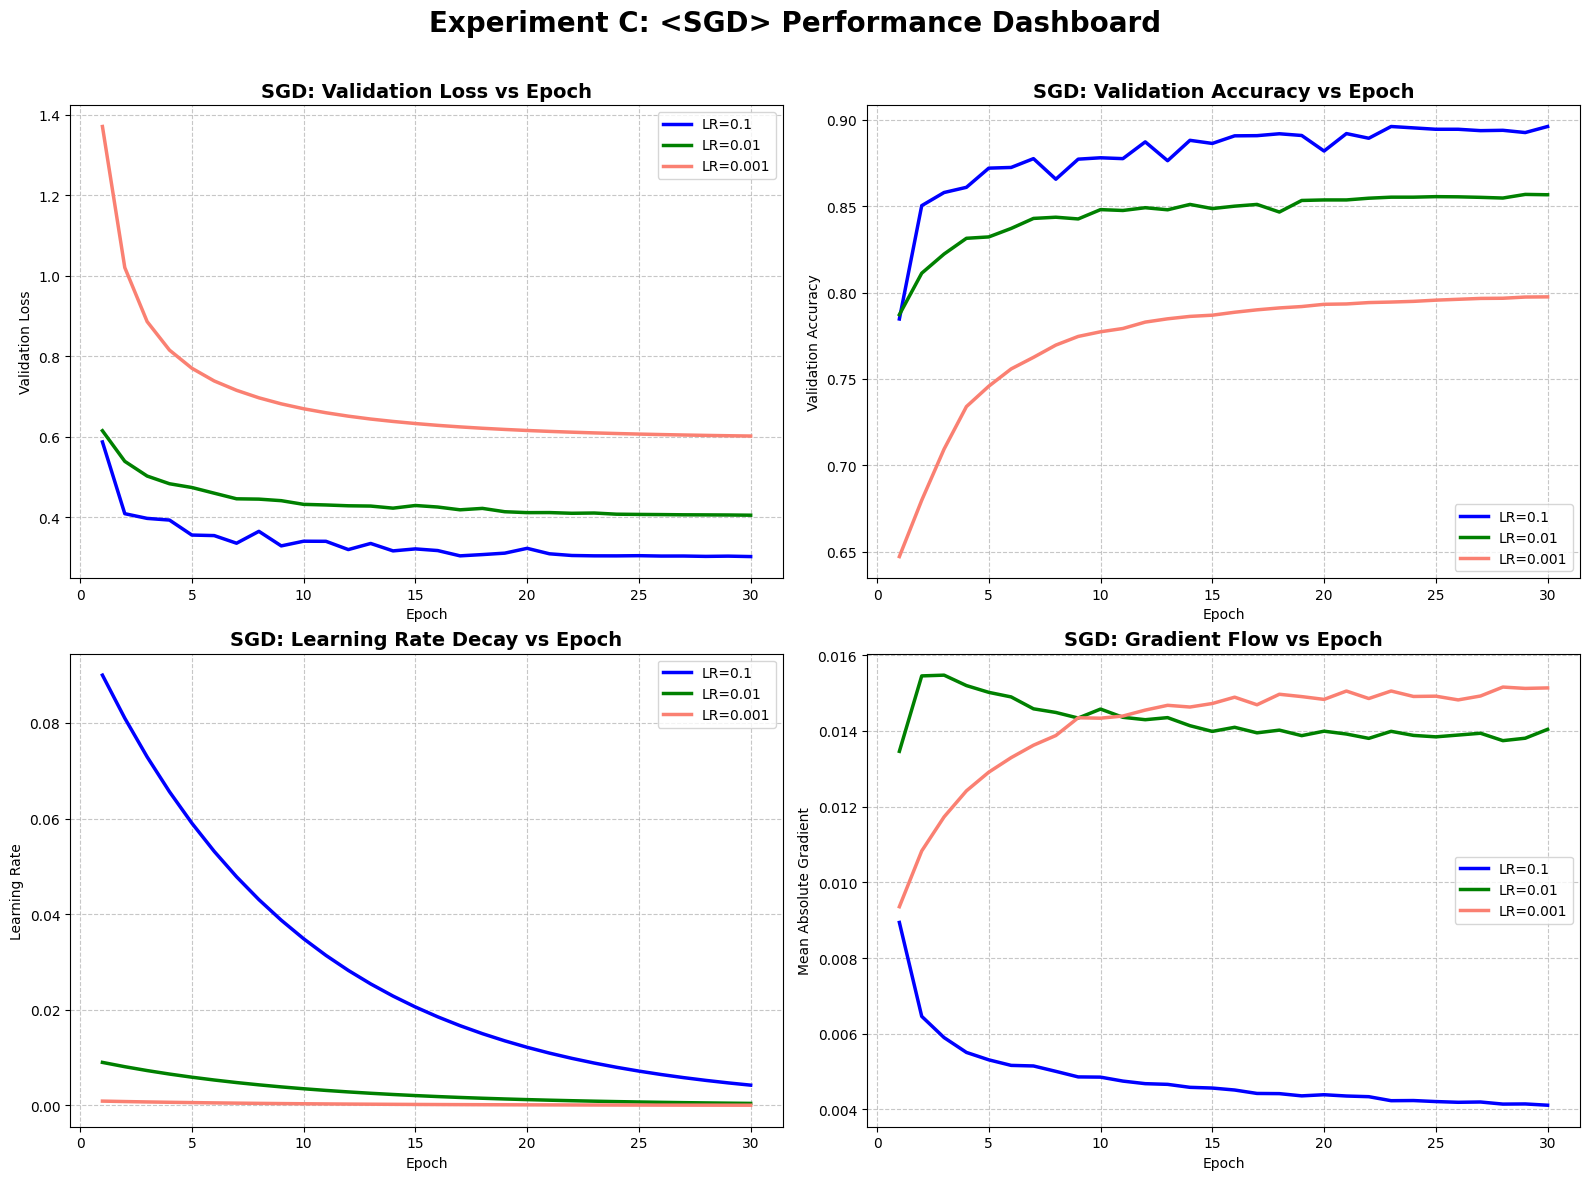

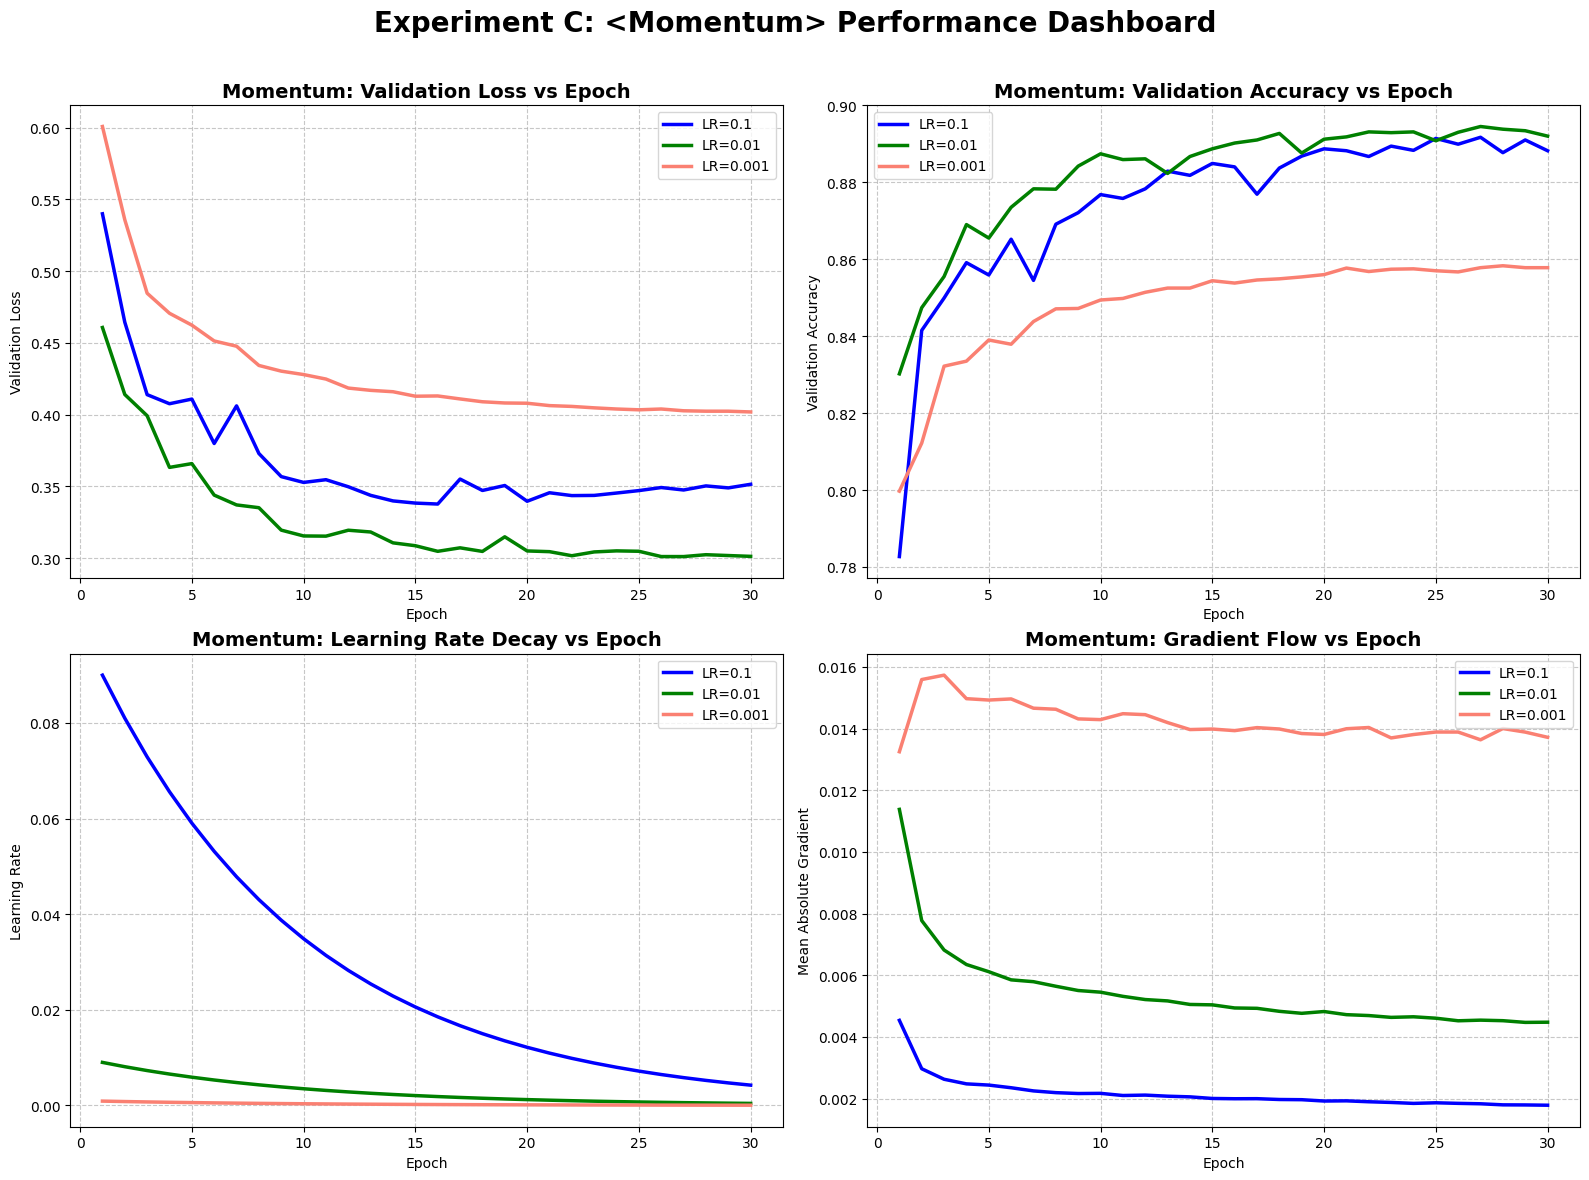

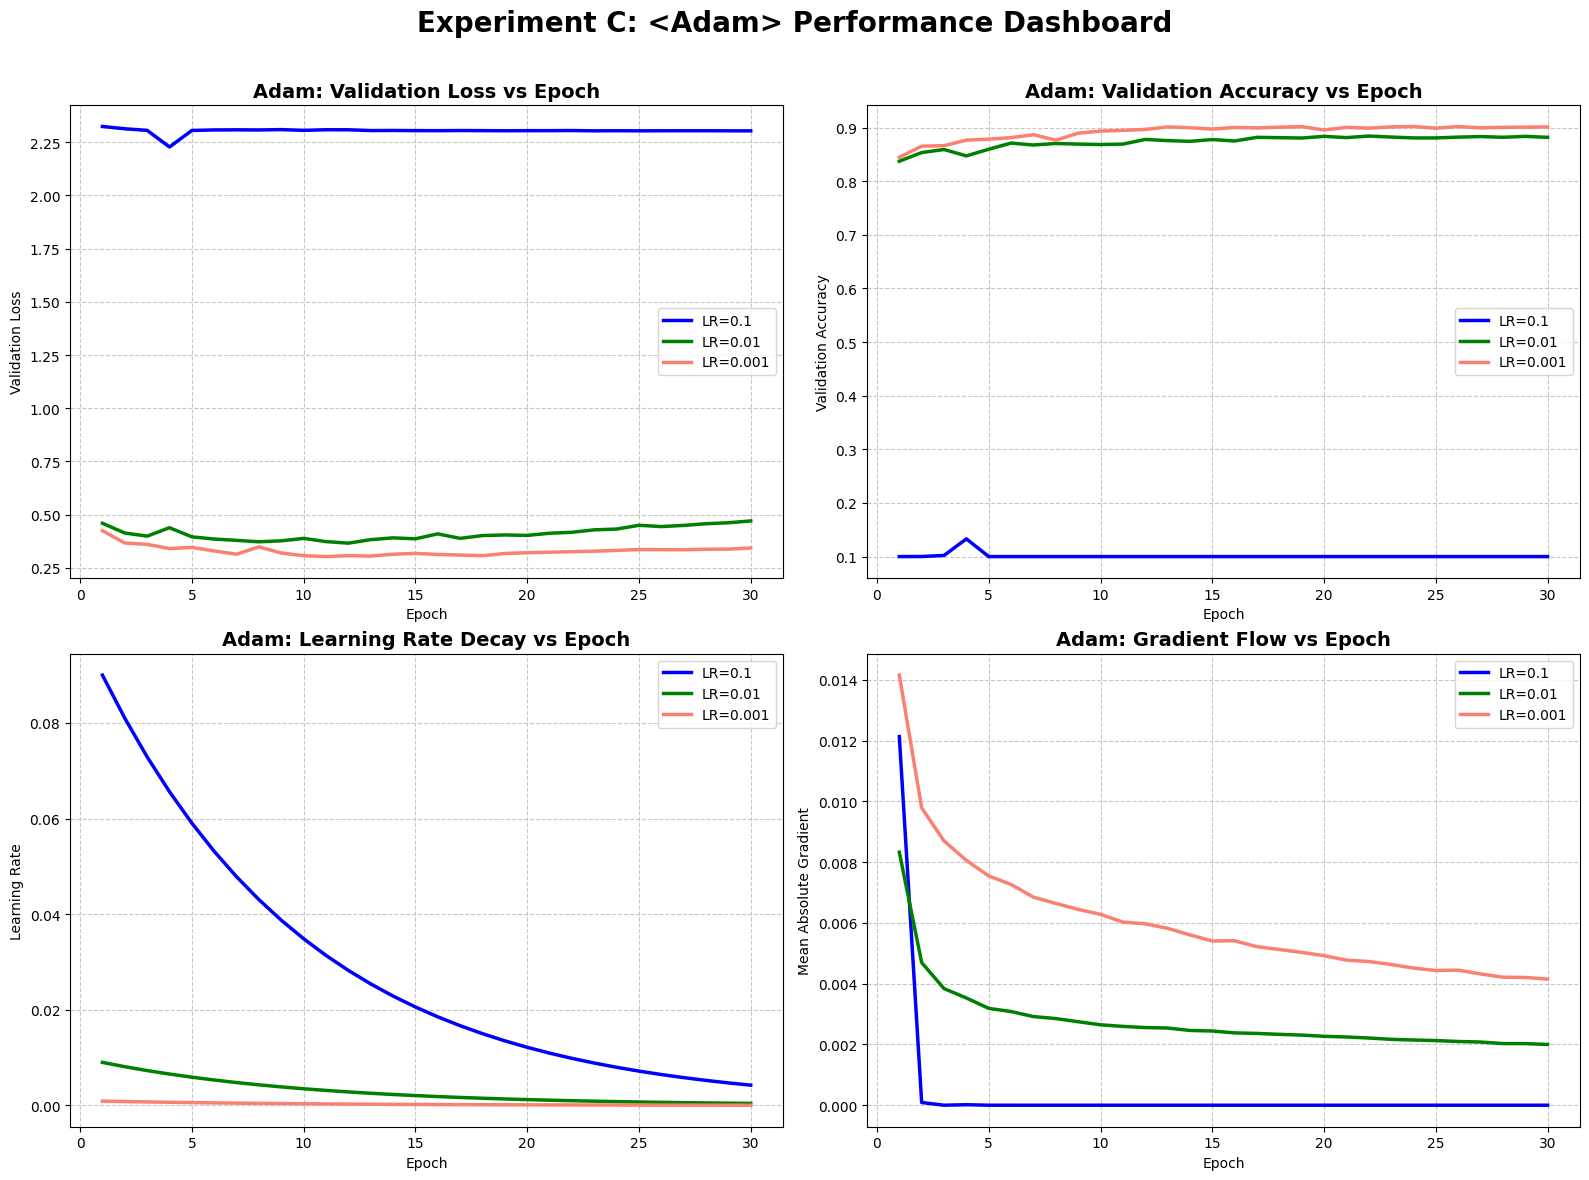

In [ ]:
def run_exp_c(opt_name, lr_init, use_scheduler=True, epochs=30):
    sched_str = "Scheduler" if use_scheduler else "NoScheduler"
    print(f"\n--- 실험 C: {opt_name} (LR: {lr_init}, {sched_str}) 학습 시작 ---")
    tf.random.set_seed(42)
    model = get_mnist_model() # 모델 생성 함수 (사전에 정의되어 있어야 함)

    steps_per_epoch = len(ds_train_f)

    # 스케줄러 사용 여부에 따른 분기 (가이드라인: LR Decay 적용)
    if use_scheduler:
        lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=lr_init, decay_steps=steps_per_epoch, decay_rate=0.9, staircase=True
        )
    else:
        lr_schedule = lr_init # 고정 학습률

    # 옵티마이저 설정
    if opt_name == 'SGD':
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)
    elif opt_name == 'Momentum':
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
    history = {'val_loss': [], 'val_acc': [], 'grad_mean': [], 'lr_curve': []}

    for epoch in range(epochs):
        v_loss = tf.keras.metrics.Mean()
        v_acc = tf.keras.metrics.CategoricalAccuracy()
        grads_epoch = []

        # Train Loop
        for x, y in ds_train_f:
            with tf.GradientTape() as tape:
                _, _, logits = model(x, training=True)
                loss = loss_fn(y, logits)
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            grads_epoch.append(tf.reduce_mean(tf.abs(grads[-2])).numpy())

        # Validation Loop
        for x_val, y_val in ds_val_f:
            _, _, val_logits = model(x_val, training=False)
            v_loss.update_state(loss_fn(y_val, val_logits))
            v_acc.update_state(y_val, tf.nn.softmax(val_logits))

        history['val_loss'].append(v_loss.result().numpy())
        history['val_acc'].append(v_acc.result().numpy())
        history['grad_mean'].append(np.mean(grads_epoch))

        # 학습률 추적
        if callable(optimizer.learning_rate):
            current_lr = optimizer.learning_rate(optimizer.iterations).numpy()
        else:
            lr_val = optimizer.learning_rate
            current_lr = lr_val.numpy() if hasattr(lr_val, 'numpy') else float(lr_val)

        history['lr_curve'].append(current_lr)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:02d}/{epochs} | Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]*100:.2f}% | LR: {current_lr:.6f}")

    return history

EPOCHS_C = 30
schedulers = [True, False]

# 옵티마이저별 Learning Rate 범위 적용
lr_guide = {
    'SGD': [0.1, 0.05, 0.01],         # 가이드: 0.01 ~ 0.1
    'Momentum': [0.05, 0.02, 0.01],   # 가이드: 0.01 ~ 0.05
    'Adam': [0.01, 0.005, 0.001]      # 가이드: 0.001 ~ 0.01
}

# 결과를 저장할 3차원 딕셔너리 구조 생성
res_opt = {opt: {} for opt in lr_guide.keys()}

# 학습 실행 루프
for opt, lrs in lr_guide.items():
    for lr in lrs:
        res_opt[opt][lr] = {}
        for use_sched in schedulers:
            res_opt[opt][lr][use_sched] = run_exp_c(opt, lr, use_scheduler=use_sched, epochs=EPOCHS_C)